## Carga de Datos

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/home/cinammoroll/7moSemestre/PortafolioTrabajosExtracurriculares/Datasets/imdb_top_1000.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Exploracion de datos

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [18]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [19]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

## Limpieza de datos

In [20]:
df["Gross"] = df["Gross"].str.replace(",", "")
df["Gross"] = df["Gross"].str.replace("$", "")
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")
df["Gross"].head()

0     28341469.0
1    134966411.0
2    534858444.0
3     57300000.0
4      4360000.0
Name: Gross, dtype: float64

In [24]:
df["Gross"].describe()

count    7.140000e+02
mean     7.851359e+07
std      1.149780e+08
min      1.305000e+03
25%      6.157408e+06
50%      3.485015e+07
75%      1.024641e+08
max      9.366622e+08
Name: Gross, dtype: float64

In [21]:
df = df.dropna(subset=["Certificate","Meta_score","Gross"]) # limpiar filas con valores nulos en columnas importantes

In [27]:
df["Main_Genre"] = df["Genre"].str.split(",").str[0]

In [30]:
df["Runtime"] = df["Runtime"].str.replace(" min", "")
df["Runtime"] = pd.to_numeric(df["Runtime"])

In [31]:
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 997
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    714 non-null    object 
 1   Series_Title   714 non-null    object 
 2   Released_Year  713 non-null    float64
 3   Certificate    714 non-null    object 
 4   Runtime        714 non-null    int64  
 5   Genre          714 non-null    object 
 6   IMDB_Rating    714 non-null    float64
 7   Overview       714 non-null    object 
 8   Meta_score     714 non-null    float64
 9   Director       714 non-null    object 
 10  Star1          714 non-null    object 
 11  Star2          714 non-null    object 
 12  Star3          714 non-null    object 
 13  Star4          714 non-null    object 
 14  No_of_Votes    714 non-null    int64  
 15  Gross          714 non-null    float64
 16  decade         713 non-null    float64
 17  Main_Genre     714 non-null    object 
dtypes: float64(5), 

# Graficas

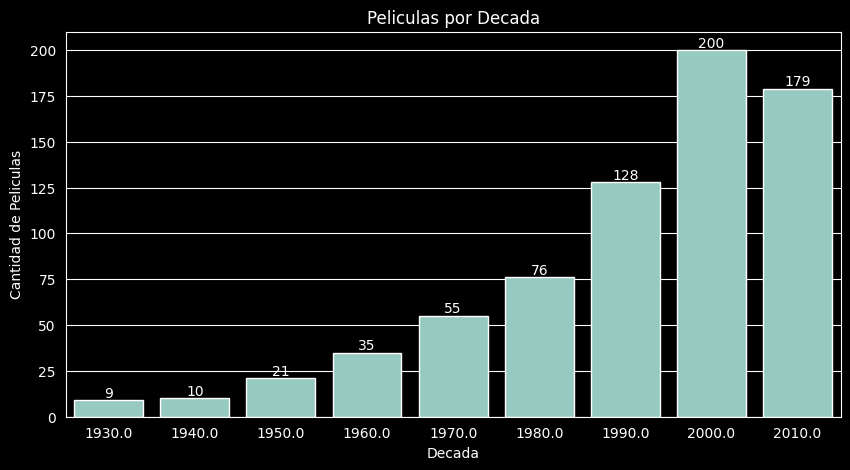

In [22]:
df["decade"] = (df["Released_Year"] // 10) * 10
decade_counts = df["decade"].value_counts().sort_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=decade_counts.index, y=decade_counts.values)
ax.bar_label(ax.containers[0])

plt.title("Peliculas por Decada")
plt.xlabel("Decada")
plt.ylabel("Cantidad de Peliculas")
plt.show()


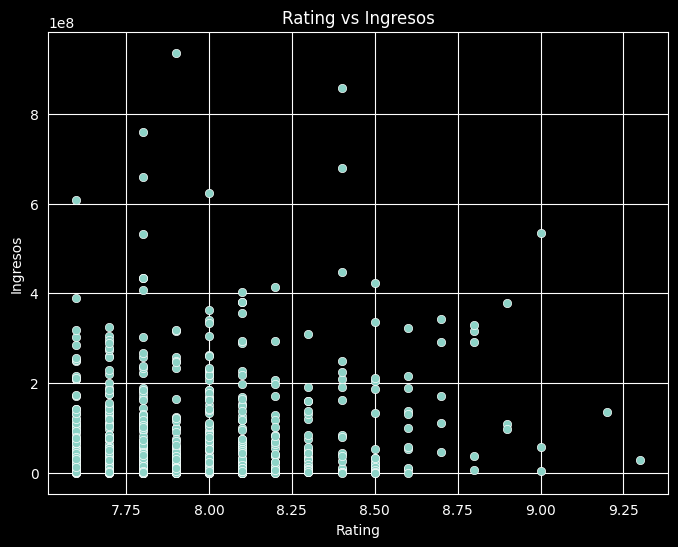

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="IMDB_Rating",
    y="Gross",
    data=df
)

plt.title("Rating vs Ingresos")
plt.xlabel("Rating")
plt.ylabel("Ingresos")

plt.show()

### En esta grafica se observa que no hay una correlacion clara entre el rating y los ingresos, lo que sugiere que otros factores como el marketing, la popularidad o el género pueden influir más en los ingresos que la calidad percibida de la película.

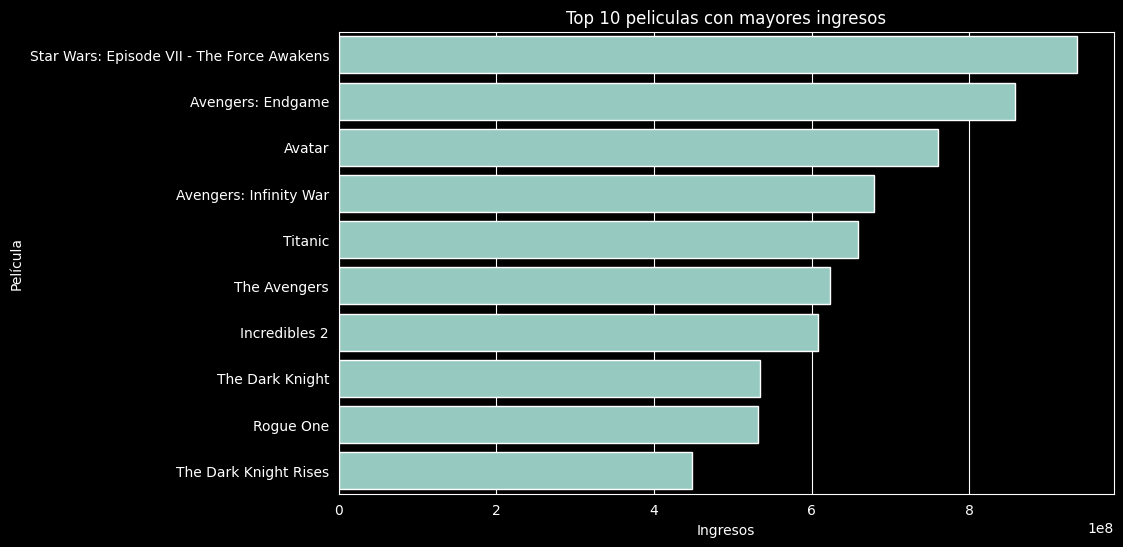

In [26]:
top_movies = df.sort_values(by="Gross", ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Gross",
    y="Series_Title",
    data=top_movies
)

plt.title("Top 10 peliculas con mayores ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Película")

plt.show()

### En esta grafica se observa que las peliculas con mayores ingresos no siempre tienen los mejores ratings, lo que sugiere que factores como el marketing, la popularidad o el género pueden influir más en los ingresos que la calidad percibida de la película.

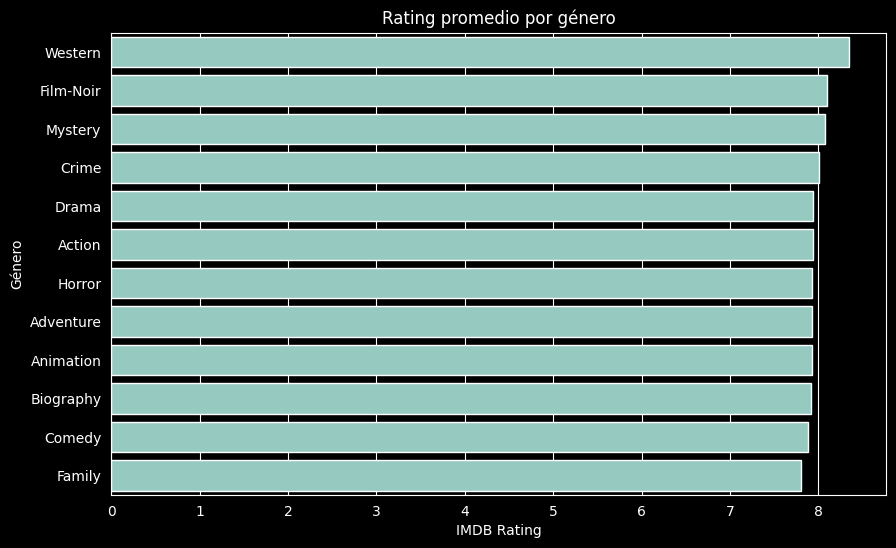

In [28]:
genre_rating = df.groupby("Main_Genre")["IMDB_Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_rating.values,
    y=genre_rating.index
)

plt.title("Rating promedio por género")
plt.xlabel("IMDB Rating")
plt.ylabel("Género")

plt.show()

### Se ha observado que algunas peliculas con ratings moderados generan ingresos mas altos, lo que sugiere que el marketing o la popularidad pueden influir mas que la calificacion.

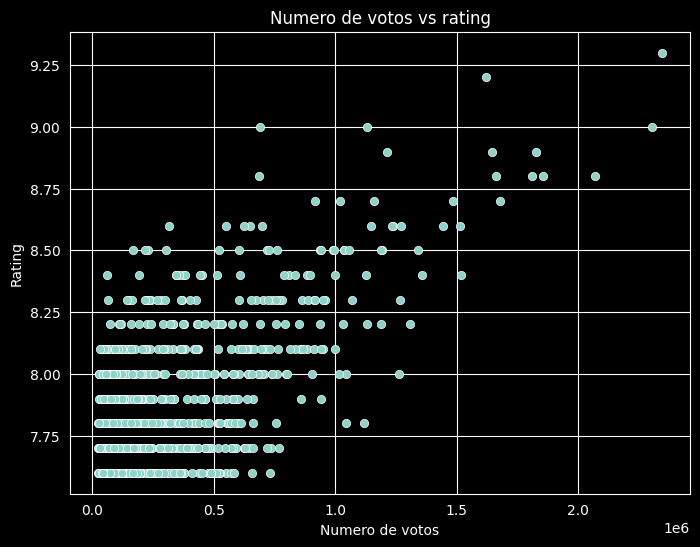

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="No_of_Votes",
    y="IMDB_Rating",
    data=df
)

plt.title("Numero de votos vs rating")
plt.xlabel("Numero de votos")
plt.ylabel("Rating")

plt.show()

### En esta grafica se observa una tendencia positiva, lo que sugiere que las peliculas con mas votos tienden a tener mejores calificaciones. Sin embargo, hay excepciones, ya que algunas peliculas con muchos votos tienen ratings moderados, lo que indica que la popularidad no siempre se traduce en alta calidad.

# Correlacion entre variables

In [34]:
numeric_df = df[[
    "IMDB_Rating",
    "Runtime",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]]

corr = numeric_df.corr()

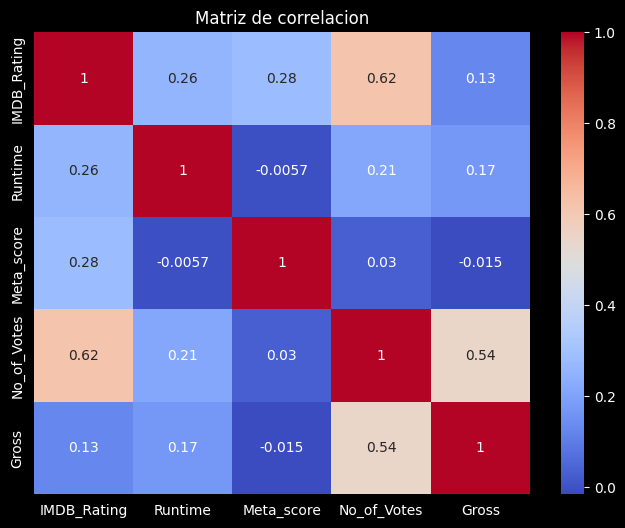

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlacion")

plt.show()

### Como se puede observar en la grafica de calor, el numero de votos tiene una correlacion positiva moderada con el rating, lo que sugiere que las peliculas con mas votos tienden a tener mejores calificaciones. Sin embargo, el gross (Ingresos) no muestra una correlacion fuerte con el rating, lo que indica que los ingresos no necesariamente reflejan la calidad percibida de la pelicula. Sin embargo el numero de votos si tiene una correlacion moderada con los ingresos, lo que sugiere que las peliculas mas populares tienden a generar mas ingresos, independientemente de su calificacion.

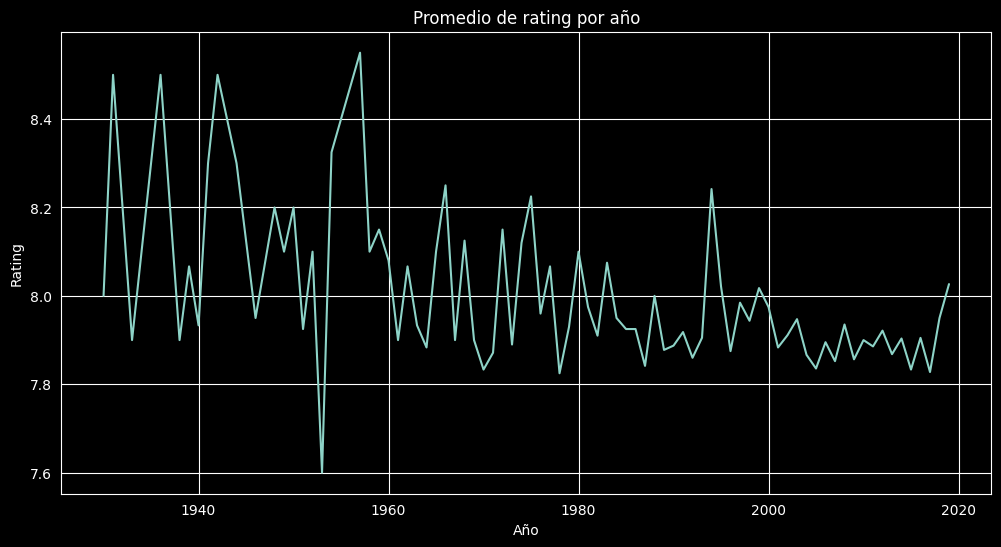

In [38]:
year_rating = df.groupby("Released_Year")["IMDB_Rating"].mean()

plt.figure(figsize=(12,6))

year_rating.plot()

plt.title("Promedio de rating por año")
plt.xlabel("Año")
plt.ylabel("Rating")

plt.show()

### En esta grafica se observa que el rating promedio de las peliculas ha tenido altibajos a lo largo de los años, con picos notables en ciertos periodos. Esto podría estar relacionado con cambios en la industria cinematográfica, tendencias culturales o la calidad general de las producciones en esos años.

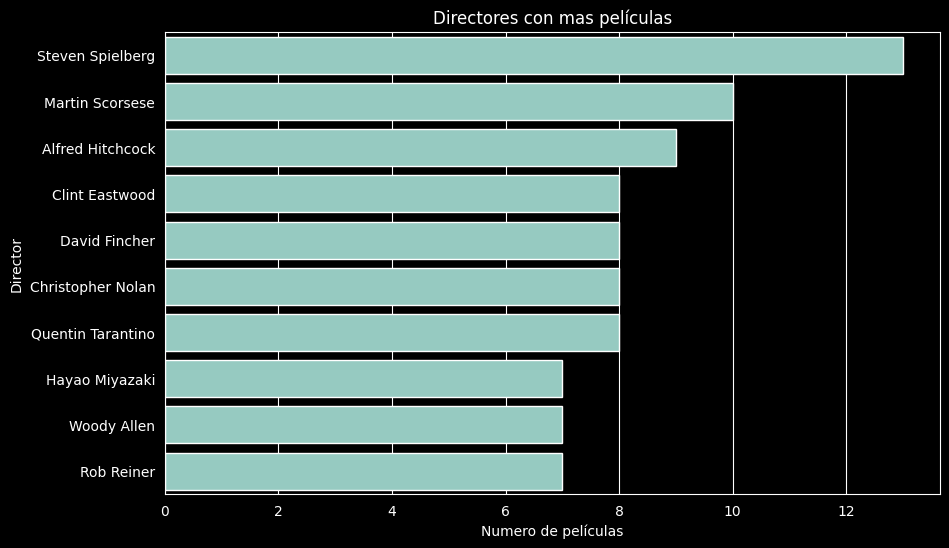

In [39]:
top_directors = df["Director"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Directores con mas películas")
plt.xlabel("Numero de películas")
plt.ylabel("Director")

plt.show()

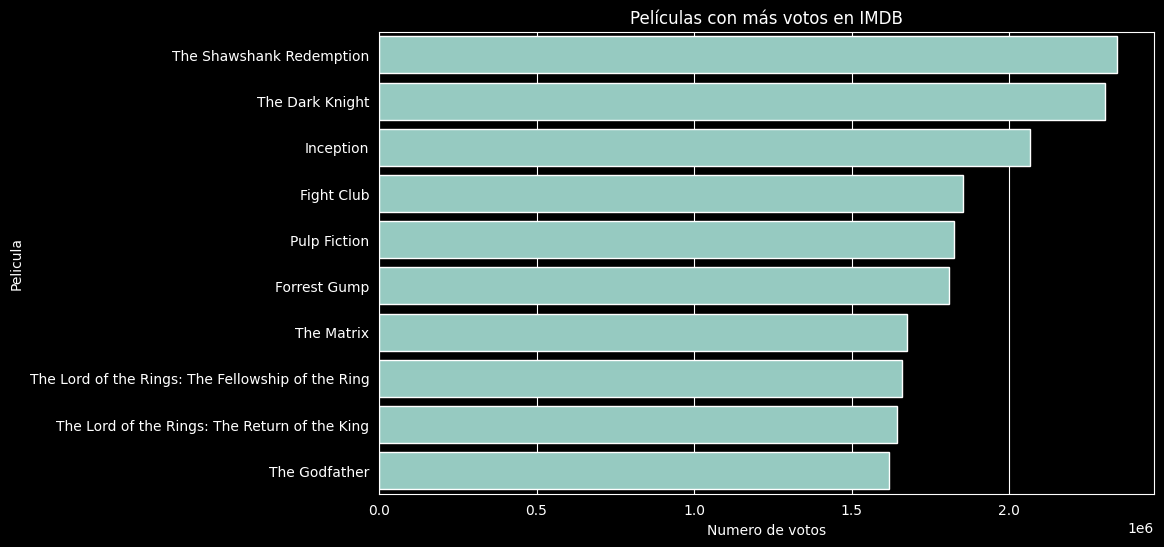

In [41]:
top_movies_votes = df.sort_values(
    by="No_of_Votes",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="No_of_Votes",
    y="Series_Title",
    data=top_movies_votes
)

plt.title("Películas con más votos en IMDB")
plt.xlabel("Numero de votos")
plt.ylabel("Pelicula")
plt.show()

# Dataset limpio

In [44]:
df.to_csv("/home/cinammoroll/7moSemestre/PortafolioTrabajosExtracurriculares/Datasets/DatasetsLimpios/movies_clean.csv", index=False)